In [1]:
!python -m pip install -r requirements.txt
import os
import numpy as np
import torch
import clip

from PIL import Image
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

  Cloning https://github.com/openai/CLIP.git to C:\Users\aandr\AppData\Local\Temp\pip-req-build-kf9s3k5p
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\aandr\AppData\Local\Temp\pip-req-build-kf9s3k5p'


# Carga del modelo CLIP

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# Cargar y preprocesar imagenes

In [5]:
base_folder = os.path.abspath("../test")
folders = ["cow", "horse", "Nilgai", "water buffelo"]

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp")

# Rutas completas
image_paths = [
    os.path.join(base_folder, sub_folder, file)
    for sub_folder in folders
    for file in os.listdir(os.path.join(base_folder, sub_folder))
    if file.lower().endswith(valid_extensions)
]

images = []

for path in image_paths:
    try:
        image = preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
        images.append(image)
    except Exception as e:
        print(f"Error cargando {path}: {e}")

# Agrupación por parte del modelo

In [6]:
image_features = []

with torch.no_grad():
    for img in images:
        features = model.encode_image(img)

        # Normalización
        features /= features.norm(dim=-1, keepdim=True)

        image_features.append(features.cpu().numpy())

X = np.vstack(image_features)

print("Shape embeddings:", X.shape)

Shape embeddings: (32, 512)


# Reducción de espacio multidimensional a 2D

In [30]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

tsne = TSNE(
    n_components=2,
    perplexity=5,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

In [34]:
n_clusters = len(folders)

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_
centroids_2d = pca.transform(centroids)

# Visualizaciones

In [35]:
def plot_with_images(points, image_paths, title, clusters, centroids_2d):

    fig, ax = plt.subplots(figsize=(12, 8))

    ax.scatter(
        points[:, 0],
        points[:, 1]
    )

    # Agregar miniaturas
    for i, path in enumerate(image_paths):

        img = Image.open(path).convert("RGB")
        img = img.resize((40, 40))

        imagebox = OffsetImage(img, zoom=1)

        ab = AnnotationBbox(
            imagebox,
            (points[i, 0], points[i, 1]),
            frameon=True,
            pad=0.2,
            bboxprops=dict(
                edgecolor=plt.cm.tab10(clusters[i]),
                linewidth=3
            )
        )

        ax.add_artist(ab)
        
    ax.scatter(
        centroids_2d[:, 0],
        centroids_2d[:, 1],
        marker='X',
        s=600,
        linewidths=3,
        edgecolors='black',
        label='Centroides'
    )

    # Etiquetas centroides
    for i, c in enumerate(centroids_2d):

        ax.text(
            c[0],
            c[1],
            f"C{i}",
            fontsize=14
        )

    ax.set_title(title)
    plt.show()

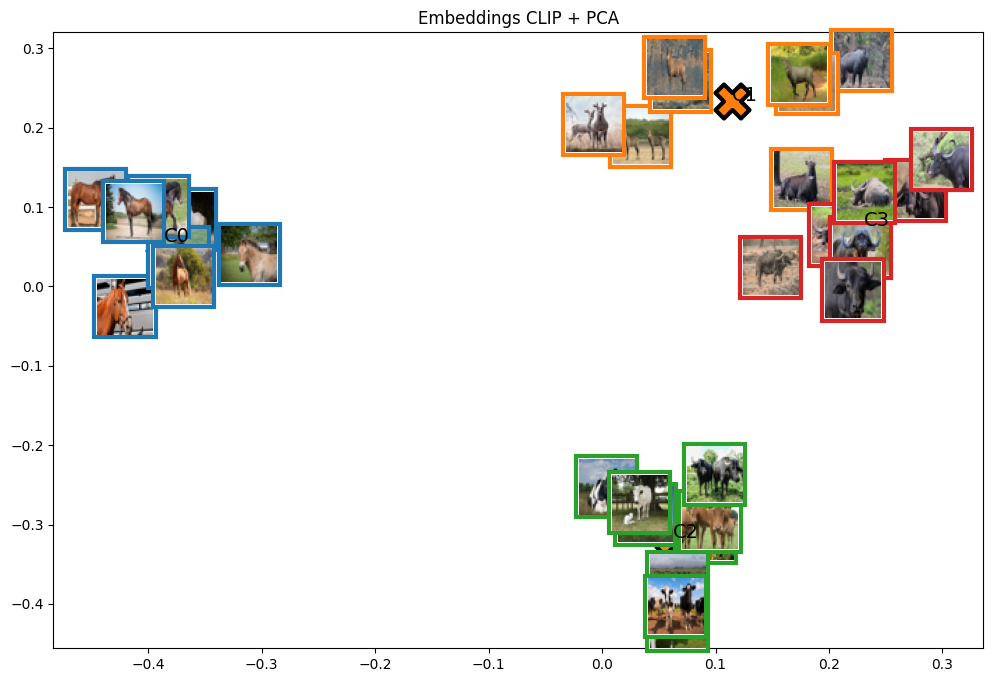

In [36]:
plot_with_images(
    X_pca,
    image_paths,
    "Embeddings CLIP + PCA",
    clusters,
    centroids_2d
)

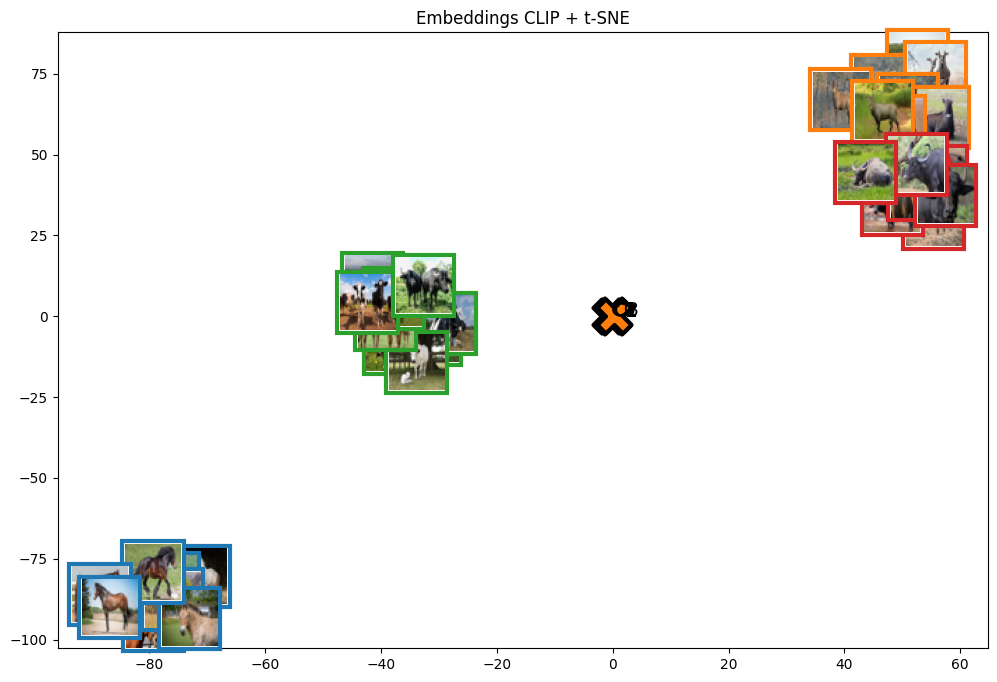

In [37]:
plot_with_images(
    X_tsne,
    image_paths,
    "Embeddings CLIP + t-SNE",
    clusters,
    centroids_2d
)

# Prompt embeddings y proyectadas

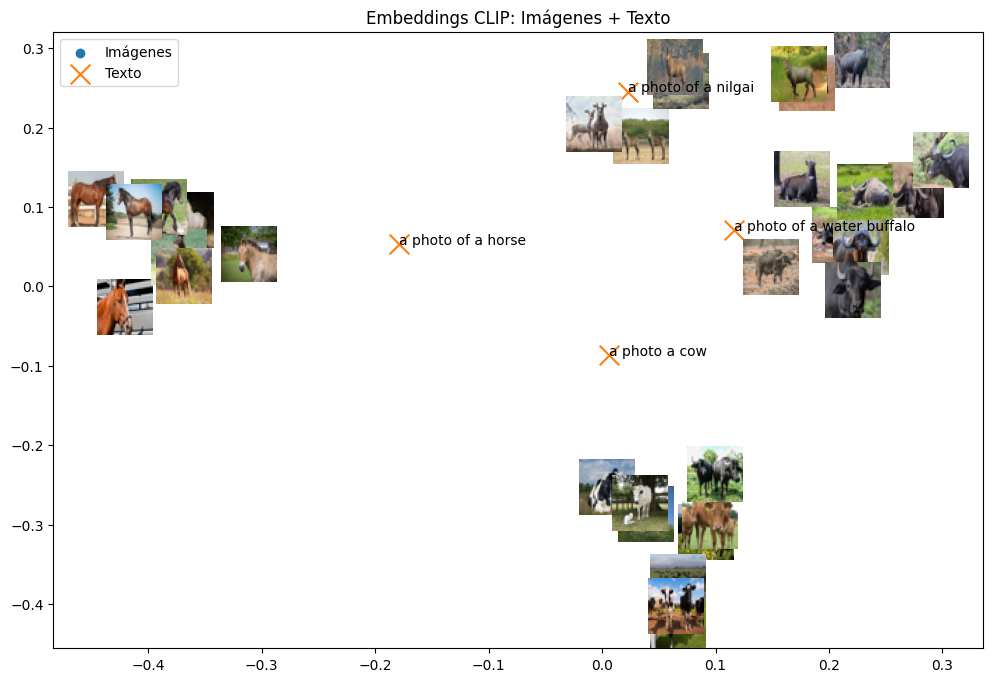

In [38]:
text_prompts = [
    "a photo a cow",
    "a photo of a horse",
    "a photo of a water buffalo",
    "a photo of a nilgai"
]

# Tokenización
text_tokens = clip.tokenize(text_prompts).to(device)

# Embeddings de texto
with torch.no_grad():

    text_features = model.encode_text(text_tokens)

    # Normalización
    text_features /= text_features.norm(dim=-1, keepdim=True)

text_features = text_features.cpu().numpy()

# Proyectar texto usando el mismo pca
text_points = pca.transform(text_features)

fig, ax = plt.subplots(figsize=(12, 8))

# Imágenes
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    label="Imágenes"
)

# Miniaturas
for i, path in enumerate(image_paths):

    img = Image.open(path).convert("RGB")
    img = img.resize((40, 40))

    imagebox = OffsetImage(img, zoom=1)

    ab = AnnotationBbox(
        imagebox,
        (X_pca[i, 0], X_pca[i, 1]),
        frameon=False
    )

    ax.add_artist(ab)

# Textos
ax.scatter(
    text_points[:, 0],
    text_points[:, 1],
    marker='x',
    s=200,
    label="Texto"
)

for i, txt in enumerate(text_prompts):

    ax.text(
        text_points[i, 0],
        text_points[i, 1],
        txt,
        fontsize=10
    )

ax.set_title("Embeddings CLIP: Imágenes + Texto")
ax.legend()

plt.show()